In [157]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os

data_folder = "./results/"
 
def get_csvs_recursive(dir_name):
    """
    recursively finds all .csv files below a specified directory and returns them as 
    a list of file paths. Usefull for combining results from multiple simulation runs.
    """
    dir_list = os.listdir(dir_name)
    cur_fnames = []
    
    for item_name in dir_list:
        # if file
        if ".csv" in item_name:
            cur_fnames += [dir_name+"/"+item_name]
        # if folder
        elif "." not in item_name:
            sub_fnames = get_csvs_recursive(dir_name+"/"+item_name)
            cur_fnames += sub_fnames
    return cur_fnames
            
    
data_fnames = get_csvs_recursive(data_folder)

# combine all files into a longform dataframe for plotting
sim_dfs= []
for filename in data_fnames:
    cur_df = pd.read_csv(filename)
    sim_dfs += [cur_df]
        
phrase_df = pd.concat(sim_dfs).reset_index(drop=True)

phrase_df["lm_config"] = "char: "+phrase_df["char_lm_type"]+", word: "+phrase_df["word_lm_type"]

phrase_df.loc[phrase_df["char_lm_type"] == "off", "char_lm_type"] = "huge (no prior)"
phrase_df.loc[phrase_df["word_lm_type"] == "off", "word_lm_type"] = "huge (no prior)"

phrase_df.tail()

,Target Phrase,Phrase Type,Typed Text,Click Load (clicks/character),Click Load (clicks/selection),Entry Rate (cpm),Entry Rate (wpm),Correction Rate (%),Error Rate (%),Word Prediction Usage (%),Session Num,Trial Num,Phrase Num,user_id,char_lm_type,word_lm_type,lm_config
1578,dad follow me please ..,iv,dad follow me please..,1.174,3.000,21.611,4.322,0.000,0.0,44.444,1,0,118,A,huge (no prior),huge (no prior),"char: off, word: off"
1579,the corner of the old gallowgate ..,oov,the corner of the old gallowgate..,2.086,2.808,11.520,2.304,7.692,0.0,23.077,1,0,119,A,huge (no prior),huge (no prior),"char: off, word: off"
1580,but it happened this year ..,iv,but it happened this year..,1.179,2.538,18.582,3.716,7.692,0.0,38.462,1,0,120,A,huge (no prior),huge (no prior),"char: off, word: off"
1581,this has given me the fear ..,iv,this has given me the fear..,1.517,3.143,14.477,2.895,7.143,0.0,50.000,1,0,121,A,huge (no prior),huge (no prior),"char: off, word: off"
1582,use an elgato video capture connector ..,oov,use an elgato video capture connector..,2.075,2.677,8.080,1.616,9.677,0.0,16.129,1,0,122,A,huge (no prior),huge (no prior),"char: off, word: off"


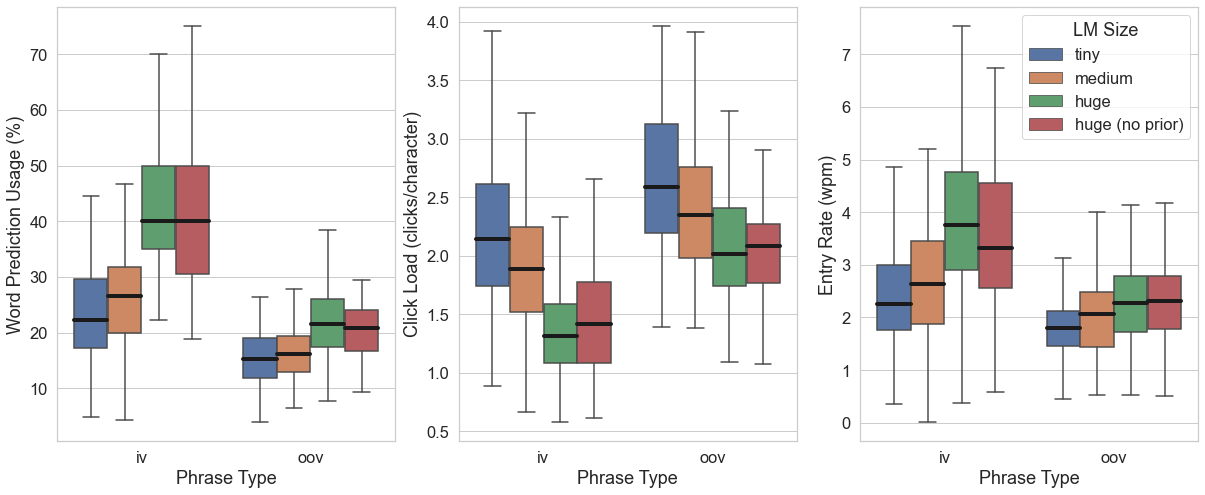

In [177]:
# setup and format a double figure for the plots
fig, axes = plt.subplots(1,3, figsize=(17, 7))
fig.tight_layout()
sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

plot_df = phrase_df.loc[phrase_df["char_lm_type"] == phrase_df['word_lm_type']]

# # plot the data as boxplots
hue_order = ['tiny', 'medium', 'huge', "huge (no prior)"]
sns.boxplot(data=plot_df, x="Phrase Type", y="Word Prediction Usage (%)", hue="char_lm_type", hue_order=hue_order, showfliers=False, medianprops={"color": "k", "linewidth": 4}, ax=axes[0])
sns.boxplot(data=plot_df, x="Phrase Type", y="Click Load (clicks/character)", hue="char_lm_type", hue_order=hue_order, showfliers=False, medianprops={"color": "k", "linewidth": 4}, ax=axes[1])
sns.boxplot(data=plot_df, x="Phrase Type", y="Entry Rate (wpm)", hue="char_lm_type", hue_order=hue_order, showfliers=False, medianprops={"color": "k", "linewidth": 4}, ax=axes[2])
axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[2].get_legend().set_title("LM Size")

(-0.9, 2.9)

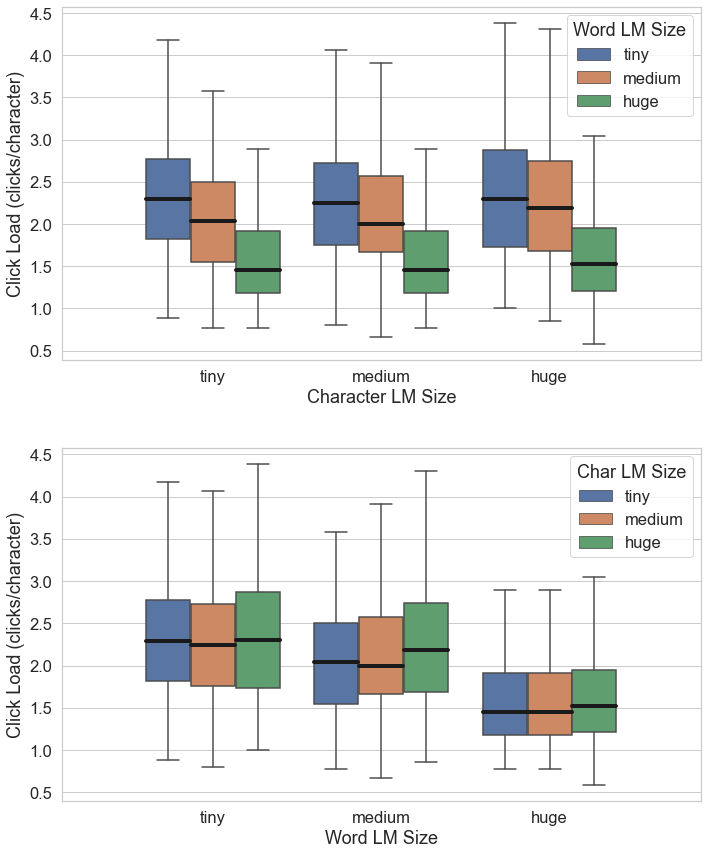

In [196]:
# setup and format a double figure for the plots
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
fig.tight_layout()
fig.subplots_adjust(hspace = 0.25, right=0.8)

sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

# plot the data as boxplots
# plot_df = phrase_df[phrase_df["Phrase Type"] == "oov"]
plot_df = phrase_df
hue_order = ['tiny', 'medium', 'huge']
sns.boxplot(data=plot_df, x="char_lm_type", y="Click Load (clicks/character)", hue="word_lm_type", hue_order=hue_order, order=hue_order, showfliers=False, medianprops={"color": "k", "linewidth": 4}, ax=axes[0])
sns.boxplot(data=plot_df, x="word_lm_type", y="Click Load (clicks/character)", hue="char_lm_type", hue_order=hue_order, order=hue_order, showfliers=False, medianprops={"color": "k", "linewidth": 4}, ax=axes[1])

axes[0].set_xlabel("Character LM Size")
axes[0].get_legend().set_title("Word LM Size")

axes[1].set_xlabel("Word LM Size")
axes[1].get_legend().set_title("Char LM Size")

axes[0].set_xlim(-0.9, 2.9)
axes[1].set_xlim(-0.9, 2.9)